In [ ]:
# 04_customer_segmentation.ipynb

##**Importing all Necessary Libraries**

In [ ]:


# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import plotly.express as px
import plotly.graph_objects as go
!pip install kneed
from kneed import KneeLocator
import scipy.cluster.hierarchy as shc
from sklearn.cluster import AgglomerativeClustering

##**Setting visualization style**

In [ ]:
# Setting visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100


##**Loading the RFM data from third phase of notebook**

In [ ]:
# Loading the RFM data from previous notebook

from google.colab import files
from google.colab import drive
drive.mount('/content/drive')
uploded = files.upload()
rfm = pd.read_csv('rfm_data.csv')

# Displaying the first few rows
display(rfm.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Saving rfm_data.csv to rfm_data (1).csv


,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,12347.0,2,7,4060.40,1,1,5,7,At Risk
1,12348.0,75,4,1186.68,4,1,4,9,Promising
2,12349.0,19,1,1353.80,2,1,4,7,At Risk
3,12350.0,310,1,294.40,5,1,2,8,New Customers
4,12352.0,36,7,1385.74,3,1,4,8,Others


##**Selecting features for clustering**

In [ ]:
# Selecting features for clustering
features = ['Recency', 'Frequency', 'Monetary']
X = rfm[features].copy()


##**Checking for any missing values**

In [ ]:
# Checking for any missing values
print("\nMissing values in the dataset:")
display(X.isnull().sum())



Missing values in the dataset:


,0
Recency,0
Frequency,0
Monetary,0


##**Handling any remaining missing values**

In [ ]:
# Handling any remaining missing values
X = X.fillna(X.mean())


##**Scaling the features**

In [ ]:
# Scaling the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

##**Descriptive Statistics**

In [ ]:
# Displaying the statistics of scaled data
print("\nScaled data statistics:")
display(X_scaled_df.describe())


Scaled data statistics:


,Recency,Frequency,Monetary
count,4.290000e+03,4.290000e+03,4.290000e+03
mean,-3.312554e-17,4.968830e-18,1.656277e-17
std,1.000117e+00,1.000117e+00,1.000117e+00
min,-9.159084e-01,-4.275201e-01,-3.340617e-01
25%,-7.458782e-01,-4.275201e-01,-2.744540e-01
50%,-4.158197e-01,-2.935492e-01,-2.023620e-01
75%,5.043435e-01,1.083634e-01,-1.352559e-02
max,2.814753e+00,2.690254e+01,3.264608e+01


##**Determining the optimal number of clusters for K-means using the elbow method**

In [ ]:
# Determining the optimal number of clusters for K-means using the elbow method
inertia = []
silhouette_scores = []
k_range = range(2, 11)


In [ ]:
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

    # Calculate silhouette score (only valid for k >= 2)
    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(score)
    print(f"K = {k}, Inertia = {kmeans.inertia_:.2f}, Silhouette Score = {score:.3f}")

K = 2, Inertia = 8899.77, Silhouette Score = 0.900
K = 3, Inertia = 5316.25, Silhouette Score = 0.573
K = 4, Inertia = 3875.40, Silhouette Score = 0.603
K = 5, Inertia = 3085.82, Silhouette Score = 0.590
K = 6, Inertia = 2588.83, Silhouette Score = 0.590
K = 7, Inertia = 2197.75, Silhouette Score = 0.503
K = 8, Inertia = 1763.20, Silhouette Score = 0.497
K = 9, Inertia = 1563.00, Silhouette Score = 0.490
K = 10, Inertia = 1359.87, Silhouette Score = 0.471


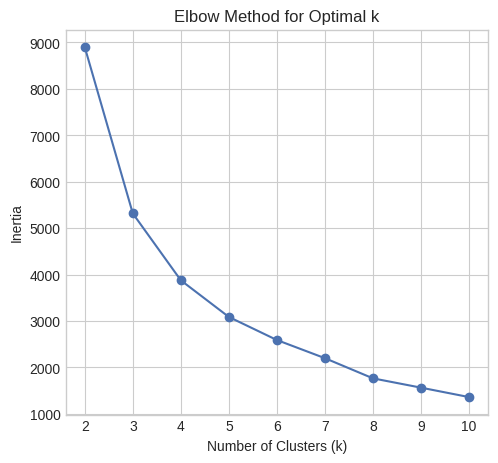

In [ ]:
# Plotting the elbow curve
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, 'o-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)

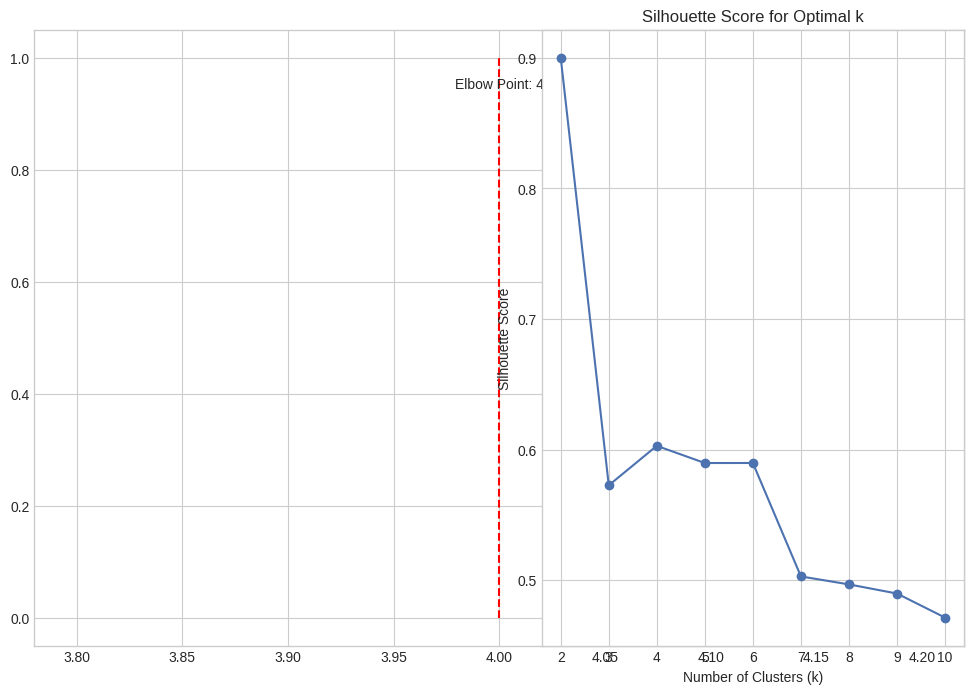

In [ ]:
# Identifying the elbow point using the kneed package
kl = KneeLocator(k_range, inertia, curve='convex', direction='decreasing')
plt.vlines(kl.elbow, plt.ylim()[0], plt.ylim()[1], linestyles='dashed', colors='r')
plt.text(kl.elbow, plt.ylim()[1]*0.9, f'Elbow Point: {kl.elbow}', ha='center')

plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, 'o-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal k')
plt.grid(True)

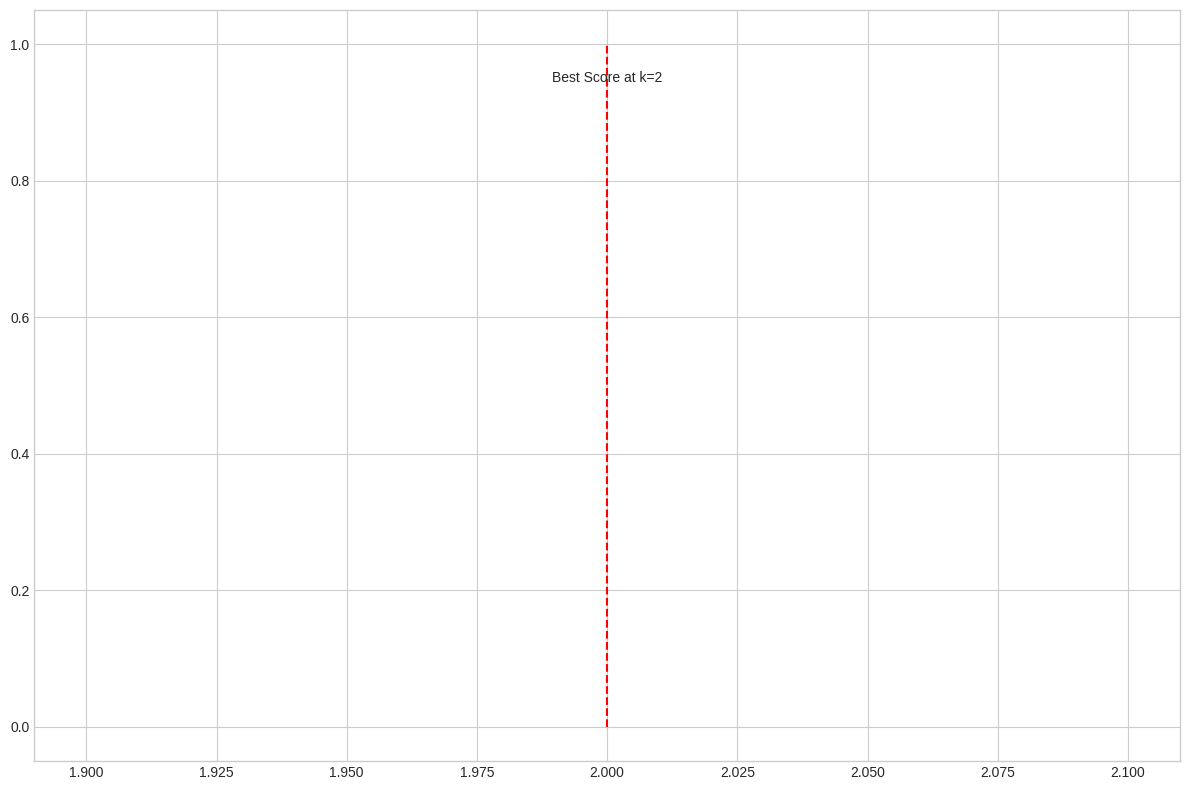

In [ ]:
# Identifying the best silhouette score
best_k_silhouette = k_range[np.argmax(silhouette_scores)]
plt.vlines(best_k_silhouette, plt.ylim()[0], plt.ylim()[1], linestyles='dashed', colors='r')
plt.text(best_k_silhouette, plt.ylim()[1]*0.9, f'Best Score at k={best_k_silhouette}', ha='center')

plt.tight_layout()
plt.show()


In [ ]:
# Based on elbow and silhouette analysis, choose the optimal k
optimal_k = kl.elbow  # You might want to choose the best silhouette score instead
print(f"\nOptimal number of clusters based on elbow method: {optimal_k}")
print(f"Optimal number of clusters based on silhouette score: {best_k_silhouette}")


Optimal number of clusters based on elbow method: 4
Optimal number of clusters based on silhouette score: 2


In [ ]:
# Considering business interpretability and choose the final number of clusters
final_k = optimal_k  # You might want to adjust this based on your analysis
print(f"Selected final number of clusters: {final_k}")


Selected final number of clusters: 4


**Selected final number of clusters: 4**

##**Applying K-means clustering with the chosen number of clusters**

In [ ]:
# Applying K-means clustering with the chosen number of clusters
kmeans = KMeans(n_clusters=final_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

In [ ]:
# Adding cluster labels to the original data
rfm['Cluster'] = clusters


##**Analyzing the clusters**

In [ ]:
# Analyzing the clusters
cluster_analysis = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Customer ID': 'count'
}).reset_index()

cluster_analysis.columns = ['Cluster', 'Avg_Recency', 'Avg_Frequency', 'Avg_Monetary', 'Customer_Count']
cluster_analysis['Customer_Percentage'] = (cluster_analysis['Customer_Count'] / cluster_analysis['Customer_Count'].sum() * 100).round(2)

print("\nCluster Analysis:")
display(cluster_analysis)


Cluster Analysis:


,Cluster,Avg_Recency,Avg_Frequency,Avg_Monetary,Customer_Count,Customer_Percentage
0,0,43.709559,3.592580,1207.708901,2992,69.74
1,1,247.457277,1.545540,439.061428,1065,24.83
2,2,12.443946,20.950673,9404.407668,223,5.20
3,3,4.900000,91.300000,74188.028000,10,0.23


##**Visualizing the clusters**

In [ ]:
# Visualizing the clusters
# Use PCA to reduce dimensions for visualization if needed
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


In [ ]:
# Creating a DataFrame with PCA results
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = clusters

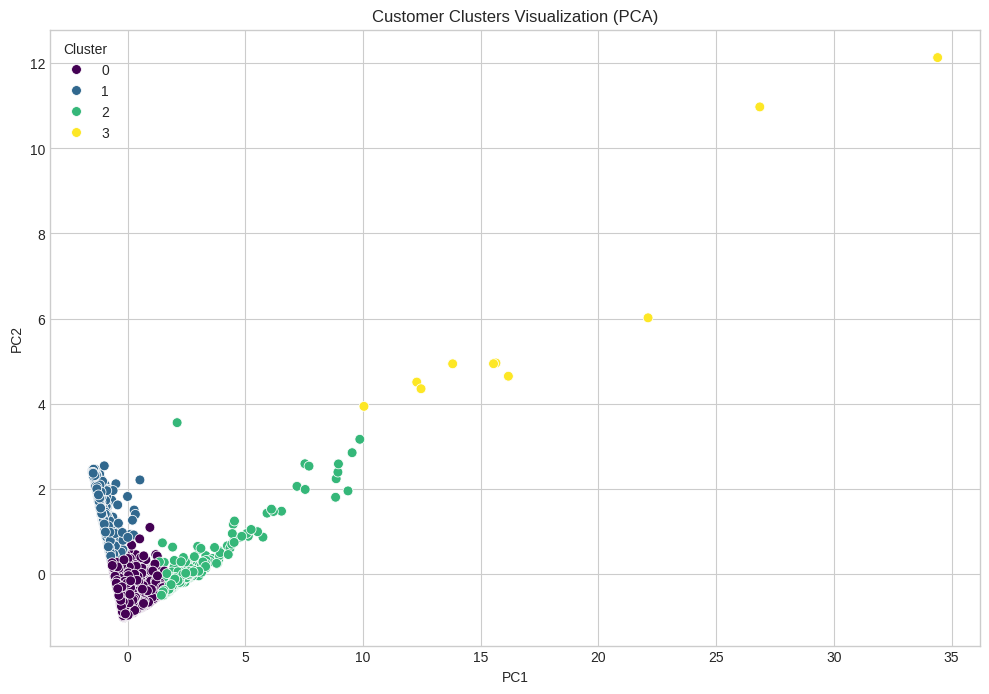

In [ ]:
# Scatter plot of clusters
plt.figure(figsize=(12, 8))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=pca_df, palette='viridis', s=50)
plt.title('Customer Clusters Visualization (PCA)')
plt.grid(True)
plt.show()

In [ ]:
# Explained variance by PCA
explained_variance = pca.explained_variance_ratio_
print(f"\nExplained variance by first two principal components: {sum(explained_variance)*100:.2f}%")


Explained variance by first two principal components: 90.19%


In [ ]:
# 3D visualization using the original features
fig = px.scatter_3d(
    rfm, x='Recency', y='Frequency', z='Monetary',
    color='Cluster', opacity=0.7,
    title='Customer Clusters in 3D RFM Space'
)
fig.update_layout(scene=dict(
    xaxis_title='Recency',
    yaxis_title='Frequency',
    zaxis_title='Monetary'
))
fig.show()

In [ ]:
# Analyzing the characteristics of each cluster
# Calculate and visualize centroids
centroids = kmeans.cluster_centers_
centroids_df = pd.DataFrame(scaler.inverse_transform(centroids), columns=features)
centroids_df['Cluster'] = range(final_k)

print("\nCluster Centroids (Original Scale):")
display(centroids_df)



Cluster Centroids (Original Scale):


,Recency,Frequency,Monetary,Cluster
0,43.709559,3.592580,1207.708901,0
1,247.457277,1.545540,439.061428,1
2,12.443946,20.950673,9404.407668,2
3,4.900000,91.300000,74188.028000,3


In [ ]:
# Parallel coordinates plot for comparing clusters
fig = px.parallel_coordinates(
    cluster_analysis,
    dimensions=['Avg_Recency', 'Avg_Frequency', 'Avg_Monetary'],
    color='Cluster',
    title='Cluster Comparison using Parallel Coordinates'
)
fig.show()

 ## **Radar chart for each cluster**

In [ ]:
# Radar chart for each cluster
def create_radar_chart(cluster_data):
    # Calculate relative values (0-1 scale) for each metric
    # For recency, lower is better so we invert it
    max_recency = cluster_data['Avg_Recency'].max()

    for i, row in cluster_data.iterrows():
        fig = go.Figure()

        # Add a trace for each cluster
        for j, cluster_row in cluster_data.iterrows():
            # Normalize metrics (0-1 scale)
            recency_norm = 1 - (cluster_row['Avg_Recency'] / max_recency)
            frequency_norm = cluster_row['Avg_Frequency'] / cluster_data['Avg_Frequency'].max()
            monetary_norm = cluster_row['Avg_Monetary'] / cluster_data['Avg_Monetary'].max()

            fig.add_trace(go.Scatterpolar(
                r=[recency_norm, frequency_norm, monetary_norm, recency_norm],
                theta=['Recency', 'Frequency', 'Monetary', 'Recency'],
                fill='toself',
                name=f'Cluster {cluster_row["Cluster"]}'
            ))

        fig.update_layout(
            polar=dict(
                radialaxis=dict(
                    visible=True,
                    range=[0, 1]
                )),
            title='Cluster Comparison using Radar Chart'
        )
        return fig

radar_fig = create_radar_chart(cluster_analysis)
radar_fig.show()

##**Defining cluster names based on characteristics**

In [ ]:
# Defining cluster names based on characteristics
def assign_cluster_name(row):
    # High value customers with recent purchases and high frequency
    if row['Avg_Recency'] < cluster_analysis['Avg_Recency'].median() and \
       row['Avg_Frequency'] > cluster_analysis['Avg_Frequency'].median() and \
       row['Avg_Monetary'] > cluster_analysis['Avg_Monetary'].median():
        return 'High-Value Active Customers'

    # High value customers but haven't purchased recently
    elif row['Avg_Recency'] > cluster_analysis['Avg_Recency'].median() and \
         row['Avg_Frequency'] > cluster_analysis['Avg_Frequency'].median() and \
         row['Avg_Monetary'] > cluster_analysis['Avg_Monetary'].median():
        return 'High-Value Churning Customers'

    # Frequent shoppers with low spending
    elif row['Avg_Frequency'] > cluster_analysis['Avg_Frequency'].median() and \
         row['Avg_Monetary'] < cluster_analysis['Avg_Monetary'].median():
        return 'Frequent Low-Spenders'

    # Recent shoppers with low frequency and spending
    elif row['Avg_Recency'] < cluster_analysis['Avg_Recency'].median() and \
         row['Avg_Frequency'] < cluster_analysis['Avg_Frequency'].median() and \
         row['Avg_Monetary'] < cluster_analysis['Avg_Monetary'].median():
        return 'New Customers'

    # Infrequent customers with high spending per order
    elif row['Avg_Frequency'] < cluster_analysis['Avg_Frequency'].median() and \
         row['Avg_Monetary'] > cluster_analysis['Avg_Monetary'].median():
        return 'Big Spenders (Infrequent)'

    # Customers that haven't shopped in a while
    elif row['Avg_Recency'] > cluster_analysis['Avg_Recency'].median() and \
         row['Avg_Frequency'] < cluster_analysis['Avg_Frequency'].median() and \
         row['Avg_Monetary'] < cluster_analysis['Avg_Monetary'].median():
        return 'Inactive Customers'

    else:
        return 'Average Customers'

##**Assigning names to clusters**

In [ ]:
# Assigning names to clusters
cluster_analysis['Cluster_Name'] = cluster_analysis.apply(assign_cluster_name, axis=1)

# Updating the main dataframe with cluster names
cluster_name_mapping = dict(zip(cluster_analysis['Cluster'], cluster_analysis['Cluster_Name']))
rfm['Cluster_Name'] = rfm['Cluster'].map(cluster_name_mapping)

# Displaying final cluster analysis with names
print("\nFinal Cluster Analysis with Names:")
display(cluster_analysis[['Cluster', 'Cluster_Name', 'Avg_Recency', 'Avg_Frequency', 'Avg_Monetary', 'Customer_Count', 'Customer_Percentage']])






Final Cluster Analysis with Names:


,Cluster,Cluster_Name,Avg_Recency,Avg_Frequency,Avg_Monetary,Customer_Count,Customer_Percentage
0,0,Inactive Customers,43.709559,3.592580,1207.708901,2992,69.74
1,1,Inactive Customers,247.457277,1.545540,439.061428,1065,24.83
2,2,High-Value Active Customers,12.443946,20.950673,9404.407668,223,5.20
3,3,High-Value Active Customers,4.900000,91.300000,74188.028000,10,0.23


In [ ]:
import os
os.makedirs('data/processed', exist_ok=True)

# Saving the clustering results
rfm.to_csv('data/processed/customer_clusters.csv', index=False)
files.download('data/processed/customer_clusters.csv')
print("\nCustomer clustering data saved to 'data/processed/customer_clusters.csv'")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Customer clustering data saved to 'data/processed/customer_clusters.csv'


##**Key insights and recommendations for each cluster**

In [ ]:
# Key insights and recommendations for each cluster
print("\n=== KEY INSIGHTS AND RECOMMENDATIONS ===")
for i, row in cluster_analysis.iterrows():
    print(f"\nCluster {row['Cluster']}: {row['Cluster_Name']}")
    print(f"Customers: {row['Customer_Count']} ({row['Customer_Percentage']}%)")
    print(f"Avg Recency: {row['Avg_Recency']:.1f} days, Avg Frequency: {row['Avg_Frequency']:.1f} orders, Avg Monetary: ${row['Avg_Monetary']:.2f}")

    # Providing specific recommendations based on cluster characteristics
    if row['Cluster_Name'] == 'High-Value Active Customers':
        print("Recommendations: Loyalty program enrollment, exclusive offers, premium customer service, early access to new products")

    elif row['Cluster_Name'] == 'High-Value Churning Customers':
        print("Recommendations: Re-engagement campaign, win-back offers, personalized communication based on past purchases")

    elif row['Cluster_Name'] == 'Frequent Low-Spenders':
        print("Recommendations: Upselling strategies, bundle offers, loyalty rewards for spending tiers")

    elif row['Cluster_Name'] == 'New Customers':
        print("Recommendations: Onboarding communications, first-time buyer incentives, educational content about product range")

    elif row['Cluster_Name'] == 'Big Spenders (Infrequent)':
        print("Recommendations: Regular reminders, subscription options, seasonal promotions")

    elif row['Cluster_Name'] == 'Inactive Customers':
        print("Recommendations: Re-activation campaign, surveys to understand reasons for inactivity, targeted offers")

    else:
        print("Recommendations: Personalized offers based on past purchases, gradual engagement building")


=== KEY INSIGHTS AND RECOMMENDATIONS ===

Cluster 0: Inactive Customers
Customers: 2992 (69.74%)
Avg Recency: 43.7 days, Avg Frequency: 3.6 orders, Avg Monetary: $1207.71
Recommendations: Re-activation campaign, surveys to understand reasons for inactivity, targeted offers

Cluster 1: Inactive Customers
Customers: 1065 (24.83%)
Avg Recency: 247.5 days, Avg Frequency: 1.5 orders, Avg Monetary: $439.06
Recommendations: Re-activation campaign, surveys to understand reasons for inactivity, targeted offers

Cluster 2: High-Value Active Customers
Customers: 223 (5.2%)
Avg Recency: 12.4 days, Avg Frequency: 21.0 orders, Avg Monetary: $9404.41
Recommendations: Loyalty program enrollment, exclusive offers, premium customer service, early access to new products

Cluster 3: High-Value Active Customers
Customers: 10 (0.23%)
Avg Recency: 4.9 days, Avg Frequency: 91.3 orders, Avg Monetary: $74188.03
Recommendations: Loyalty program enrollment, exclusive offers, premium customer service, early acces